In [1]:
import json
import re
import pandas as pd
from pathlib import Path

from pydantic import BaseModel, Field
from sklearn.metrics import mean_absolute_error

from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" / "processed"

df = pd.read_parquet(PROCESSED_DATA_DIR / "pmdata_daily_features.parquet")
df.head()


,participant_id,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std,resting_heart_rate,calories_daily,mood,fatigue,stress,sleep_quality,readiness
0,p01,2019-11-01,17873.0,NaN,NaN,NaN,66.140075,46.0,140.0,15.080539,53.741074,4009.10,3.0,2.0,3.0,3.0,5.0
1,p01,2019-11-02,13118.0,378.0,430.0,97.0,62.602226,44.0,122.0,15.280065,52.881497,3533.56,3.0,2.0,3.0,3.0,6.0
2,p01,2019-11-03,14312.0,378.0,422.0,96.0,64.551841,45.0,132.0,14.532847,53.222024,3748.73,3.0,3.0,3.0,3.0,8.0
3,p01,2019-11-04,10970.0,361.0,399.0,96.0,63.552109,44.0,126.0,13.494872,54.311141,3353.38,3.0,3.0,3.0,3.0,8.0
4,p01,2019-11-05,16186.0,326.0,362.0,99.0,66.672530,44.0,163.0,23.635823,52.259110,3794.63,3.0,3.0,3.0,3.0,8.0


In [3]:
target = "readiness"

feature_cols = [
    "steps_daily",
    "sleep_minutes",
    "time_in_bed",
    "sleep_efficiency",
    "hr_mean",
    "hr_min",
    "hr_max",
    "hr_std",
    "resting_heart_rate",
    "calories_daily",
    "mood",
]

model_df = df.dropna(subset=[target]).copy()
model_df = model_df.sort_values(["participant_id", "date"]).reset_index(drop=True)
model_df.head()


,participant_id,date,steps_daily,sleep_minutes,time_in_bed,sleep_efficiency,hr_mean,hr_min,hr_max,hr_std,resting_heart_rate,calories_daily,mood,fatigue,stress,sleep_quality,readiness
0,p01,2019-11-01,17873.0,NaN,NaN,NaN,66.140075,46.0,140.0,15.080539,53.741074,4009.10,3.0,2.0,3.0,3.0,5.0
1,p01,2019-11-02,13118.0,378.0,430.0,97.0,62.602226,44.0,122.0,15.280065,52.881497,3533.56,3.0,2.0,3.0,3.0,6.0
2,p01,2019-11-03,14312.0,378.0,422.0,96.0,64.551841,45.0,132.0,14.532847,53.222024,3748.73,3.0,3.0,3.0,3.0,8.0
3,p01,2019-11-04,10970.0,361.0,399.0,96.0,63.552109,44.0,126.0,13.494872,54.311141,3353.38,3.0,3.0,3.0,3.0,8.0
4,p01,2019-11-05,16186.0,326.0,362.0,99.0,66.672530,44.0,163.0,23.635823,52.259110,3794.63,3.0,3.0,3.0,3.0,8.0


In [4]:
eval_df = model_df.sample(30, random_state=42).copy()
eval_df = eval_df.reset_index(drop=True)
eval_df[["participant_id", "date", target]].head()

,participant_id,date,readiness
0,p06,2019-11-08,8.0
1,p11,2019-12-15,6.0
2,p06,2019-12-07,7.0
3,p16,2020-02-10,3.0
4,p11,2020-02-25,3.0


In [5]:
class ReadinessPrediction(BaseModel):
    readiness: float = Field(description="Predicted readiness score from 0 to 10")

In [6]:
llm = ChatOllama(
    model="qwen2.5:1.5b",
    base_url="http://localhost:11434",
    temperature=0
)
structured_llm = llm.with_structured_output(ReadinessPrediction)

In [11]:
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You predict daily readiness from wearable health features. "
        "You understand different features given by the users and predict based on them"
        "Return only the structured output."
    ),
    (
        "human",
        """
Predict a single numeric readiness score between 0 and 10.
Use one decimal place.

Example 1:
steps_daily=12000
sleep_minutes=420
sleep_efficiency=97
hr_mean=63
resting_heart_rate=53
calories_daily=3600
mood=3
readiness:   7.0

Example 2:
steps_daily=4000
sleep_minutes=300
sleep_efficiency=88
hr_mean=76
resting_heart_rate=61
calories_daily=2500
mood=2
readiness: "readiness": 3.0

Now predict for:
Features:
- steps_daily: {steps_daily}
- sleep_minutes: {sleep_minutes}
- time_in_bed: {time_in_bed}
- sleep_efficiency: {sleep_efficiency}
- hr_mean: {hr_mean}
- hr_min: {hr_min}
- hr_max: {hr_max}
- hr_std: {hr_std}
- resting_heart_rate: {resting_heart_rate}
- calories_daily: {calories_daily}
- mood: {mood}
"""
    )
])


In [8]:
def predict_readiness(row):
    try:
        response = (prompt | structured_llm).invoke({
            col: row[col] for col in feature_cols
        })
        return {
            "predicted_readiness": float(response.readiness),
            "parse_success": True,
            "error_message": None,
        }
    except Exception as e:
        return {
            "predicted_readiness": None,
            "parse_success": False,
            "error_message": str(e),
        }

In [12]:
results = []

for _, row in eval_df.iterrows():
    pred = predict_readiness(row)
    results.append({
        "participant_id": row["participant_id"],
        "date": row["date"],
        "actual_readiness": row[target],
        **pred
    })

results_df = pd.DataFrame(results)
results_df.head()

,participant_id,date,actual_readiness,predicted_readiness,parse_success,error_message
0,p06,2019-11-08,8.0,7.0,True,None
1,p11,2019-12-15,6.0,5.0,True,None
2,p06,2019-12-07,7.0,6.0,True,None
3,p16,2020-02-10,3.0,5.0,True,None
4,p11,2020-02-25,3.0,7.0,True,None


In [13]:
valid_results = results_df[results_df["parse_success"]].dropna(subset=["predicted_readiness"])

mae = mean_absolute_error(
    valid_results["actual_readiness"],
    valid_results["predicted_readiness"]
)

parse_failure_rate = 1 - results_df["parse_success"].mean()

mae, parse_failure_rate


(1.9733333333333334, np.float64(0.0))

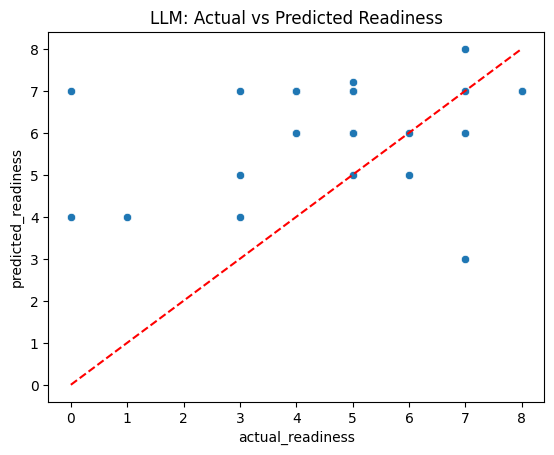

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=valid_results,
    x="actual_readiness",
    y="predicted_readiness"
)

min_val = min(valid_results["actual_readiness"].min(), valid_results["predicted_readiness"].min())
max_val = max(valid_results["actual_readiness"].max(), valid_results["predicted_readiness"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
plt.title("LLM: Actual vs Predicted Readiness")
plt.show()

Few-shot prompting improved the LLM baseline. Predictions are more varied and align better with the true readiness trend, but the model still shows weak calibration and nontrivial error.

Also the model used is not that efficient. It was used for faster inference on the laptop. Larger models could be better at prediciton.